# 4. Futures positioning (Hypothesis 3)

**Question.** Does extreme speculative futures positioning predict continuation, reversal, or nothing?

> **Data provenance.** This notebook runs on whichever source the pipeline was given. When the
> source is `SYNTHETIC`, every number below is a property of the simulator in `src/synthetic.py`
> and **not** market history. The only observed market values in the project are the three
> anchors in `config.ANCHORS`. Run `python run_pipeline.py --source fred` on a machine with
> network access to reproduce the identical analysis from live data.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd

from src import backtest, config, features, pipeline, regressions, relative_value, signals

# src.charts selects the Agg backend so the pipeline runs headless; switch back to the
# inline backend afterwards so figures render in the notebook.
%matplotlib inline
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

results = pipeline.run(write_outputs=False)
provenance = results["dataset"].provenance()
print(f"source        {provenance['source']}")
print(f"window        {provenance['start_date']} to {provenance['end_date']}")
print(f"observations  {provenance['daily_observations']:,} trading days")
print(f"validation    {results['validation_log'].summary()}")


source        SYNTHETIC
window        2016-08-15 to 2026-08-13
observations  2,512 trading days
validation    PASS=54


## The publication timing problem

CFTC Commitments of Traders positions are measured at **Tuesday's close** and published the following **Friday at 15:30 US/Eastern**. Handing Tuesday's reading to a Wednesday model gives it three days of information that did not exist. Because 15:30 ET falls inside the cash session, this pipeline does not assume a fill in the closing half hour either: a report becomes usable on the next trading session.

In [2]:
cot = results["dataset"].cot
weekly = cot.drop_duplicates("report_date")[["report_date"]].reset_index(drop=True)
weekly["available_from"] = features.cot_available_from(weekly["report_date"])
weekly["as_of_day"] = weekly["report_date"].dt.day_name()
weekly["usable_day"] = weekly["available_from"].dt.day_name()
weekly["lag_days"] = (weekly["available_from"] - weekly["report_date"]).dt.days
print(weekly.head(6).to_string(index=False))
print("\nlag distribution (7 days when that Monday is a holiday):")
print(weekly["lag_days"].value_counts().sort_index().to_string())

report_date available_from as_of_day usable_day  lag_days
 2016-08-16     2016-08-22   Tuesday     Monday         6
 2016-08-23     2016-08-29   Tuesday     Monday         6
 2016-08-30     2016-09-06   Tuesday    Tuesday         7
 2016-09-06     2016-09-12   Tuesday     Monday         6
 2016-09-13     2016-09-19   Tuesday     Monday         6
 2016-09-20     2016-09-26   Tuesday     Monday         6

lag distribution (7 days when that Monday is a holiday):
lag_days
6    470
7     52


## Normalising positioning

Raw contract counts are not comparable across markets or across time as open interest grows. The platform uses net position over open interest, then a three-year (156 week) trailing z-score, so a statement like *leveraged fund Treasury positioning is 2.1 standard deviations above its three-year mean* is well defined.

In [3]:
from src import reporting

snapshot = reporting.positioning_snapshot(results["features"], cot)
snapshot[["market", "label", "category", "report_date_tuesday", "usable_from", "net_position", "open_interest", "net_pct_of_oi", "percentile_52w", "zscore_3y", "weekly_change_pct_oi"]]

,market,label,category,report_date_tuesday,usable_from,net_position,open_interest,net_pct_of_oi,percentile_52w,zscore_3y,weekly_change_pct_oi
0,es,E-mini S&P 500,leveraged_funds,2026-08-11,2026-08-17,"-182,912.0000","2,295,781.0000",0.1086,36.5385,-0.0212,-4.3874
1,zn,10y Treasury note,leveraged_funds,2026-08-11,2026-08-17,"127,651.0000","4,271,827.0000",0.6017,51.9231,0.4369,-9.0881
2,6e,Euro FX,leveraged_funds,2026-08-11,2026-08-17,"-19,724.0000","916,233.0000",-5.8961,1.9231,-1.3907,-7.2754
3,cl,WTI crude oil,managed_money,2026-08-11,2026-08-17,"-64,569.0000","1,792,134.0000",-1.2323,17.3077,-0.6562,4.2399
4,gc,Gold,managed_money,2026-08-11,2026-08-17,"-67,886.0000","625,112.0000",-14.4839,1.9231,-2.5252,-2.3198


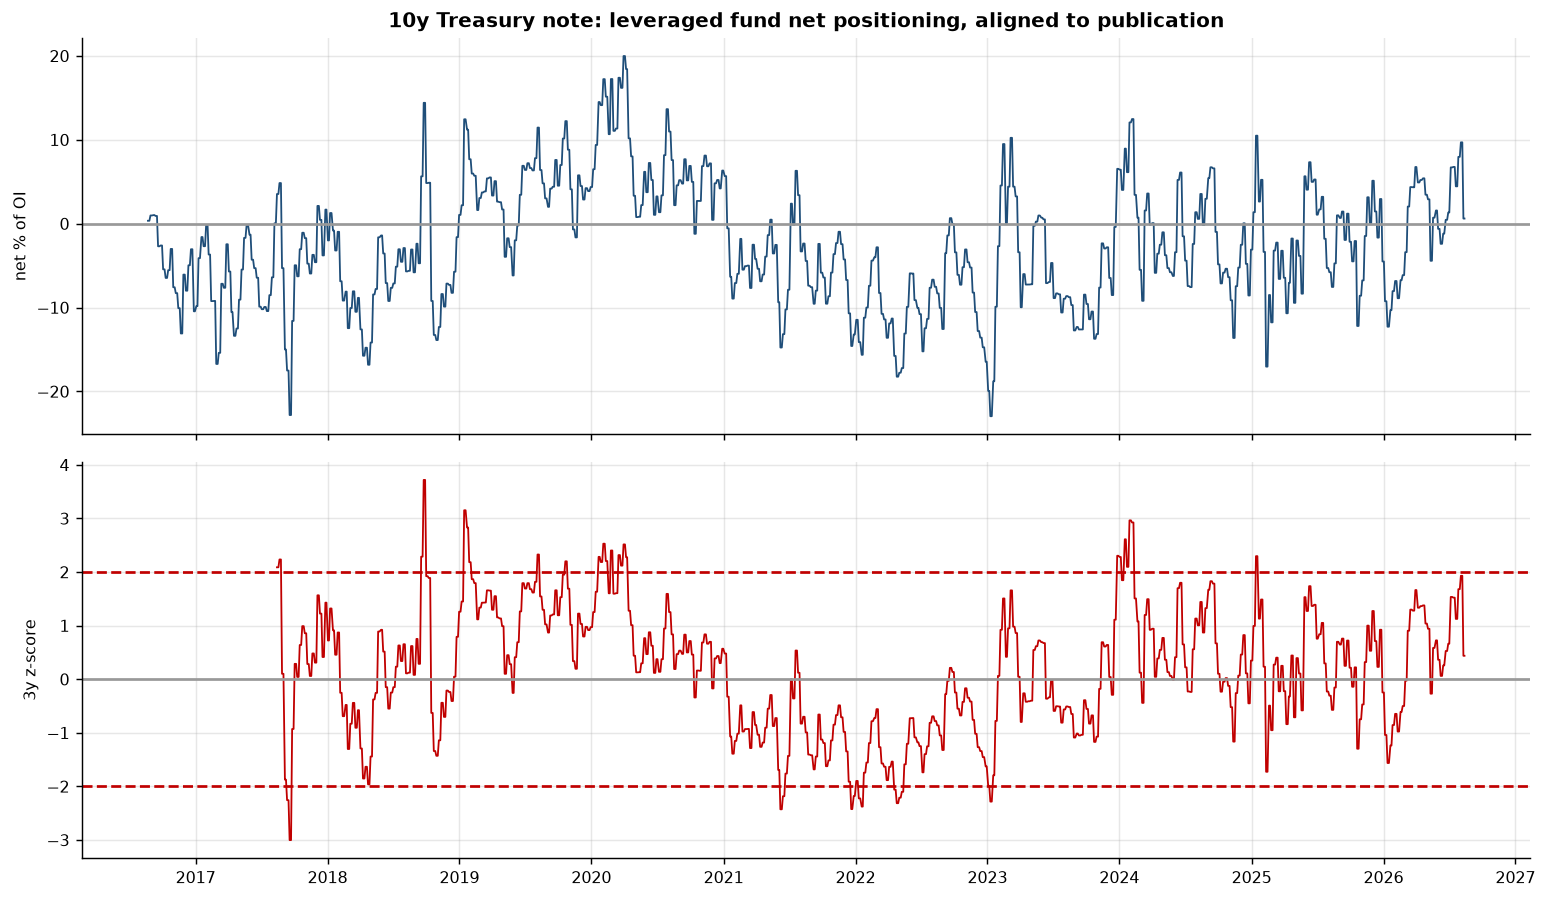

In [4]:
features_frame = results["features"]
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ratio = features_frame["cot_zn_ratio"].dropna()
axes[0].plot(ratio.index, ratio * 100, linewidth=1.0, color="#1f4e79")
axes[0].axhline(0, color="#999999"); axes[0].grid(alpha=0.3)
axes[0].set_ylabel("net % of OI")
axes[0].set_title("10y Treasury note: leveraged fund net positioning, aligned to publication")
z = features_frame["cot_zn_z156"].dropna()
axes[1].plot(z.index, z, linewidth=1.0, color="#c00000")
for level in (2, -2):
    axes[1].axhline(level, color="#c00000", linestyle="--")
axes[1].axhline(0, color="#999999"); axes[1].grid(alpha=0.3); axes[1].set_ylabel("3y z-score")
plt.tight_layout(); plt.show()

## Forward returns by positioning bucket

Buckets are the quantiles specified in advance: bottom 10%, 10-25%, 25-75%, 75-90%, top 10%. Breakpoints are cut on the full sample, so this is an **in-sample descriptive study**, not a tradable rule. Forward windows overlap heavily, so t-statistics use Newey-West standard errors; naive errors would be far too small.

In [5]:
buckets = results["positioning_buckets"]
order = ["bottom 10%", "10-25%", "25-75%", "75-90%", "top 10%"]
view = buckets[buckets["horizon_days"] == 21].pivot_table(index="bucket", columns="market", values="mean_return_pct").reindex(order)
view

market,6e,cl,es,gc,zn
bucket,,,,,
bottom 10%,0.3048,-5.7939,0.8962,1.1346,-0.1443
10-25%,-0.1090,-4.5407,-0.6824,0.7622,-1.1439
25-75%,-0.0980,1.3033,2.0365,1.4963,-0.0505
75-90%,0.3417,3.8982,1.3834,-0.3128,0.4801
top 10%,0.2559,0.7220,1.0039,1.1028,0.0993


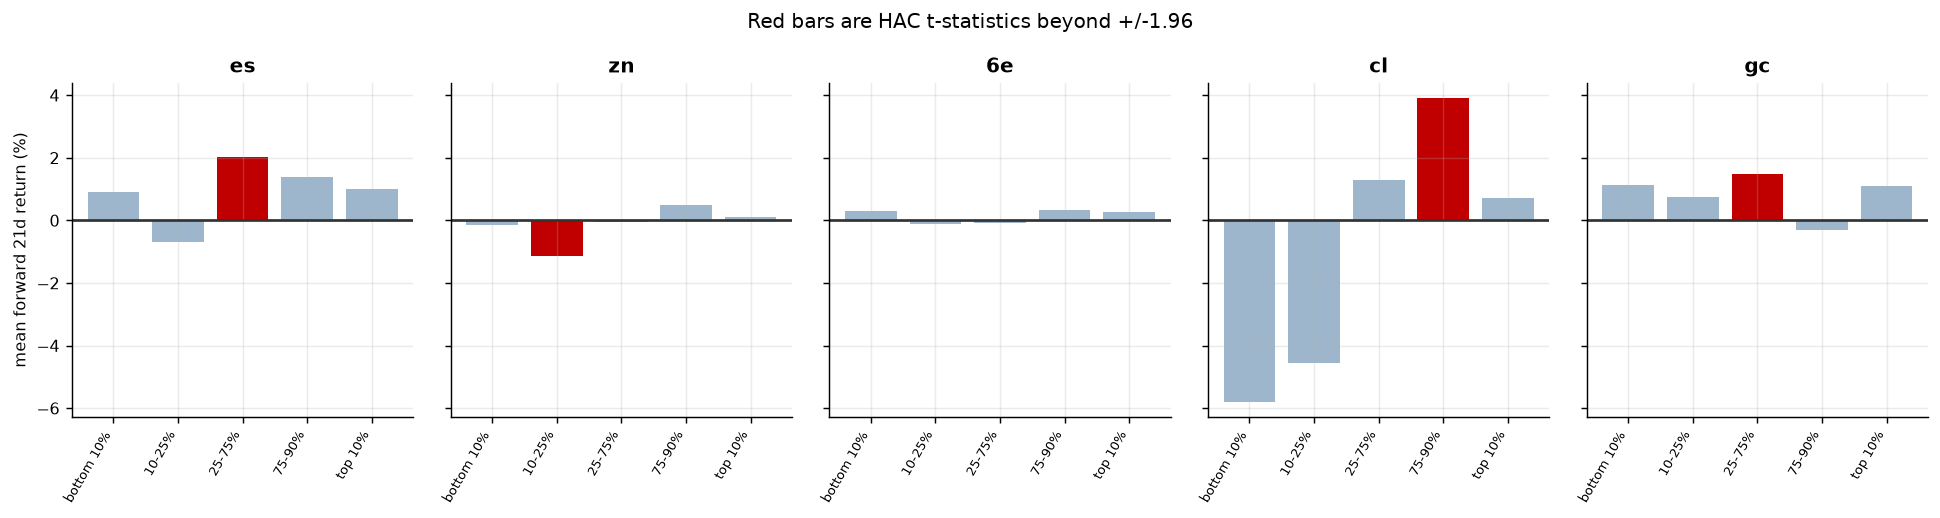

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4), sharey=True)
for ax, market in zip(axes, buckets["market"].unique()):
    rows = buckets[(buckets["market"] == market) & (buckets["horizon_days"] == 21)].set_index("bucket").reindex(order)
    colours = ["#c00000" if abs(t) > 1.96 else "#9db6cc" for t in rows["t_stat_hac"].fillna(0)]
    ax.bar(range(len(order)), rows["mean_return_pct"], color=colours)
    ax.axhline(0, color="#333333")
    ax.set_xticks(range(len(order)), order, rotation=60, ha="right", fontsize=7)
    ax.set_title(market)
axes[0].set_ylabel("mean forward 21d return (%)")
plt.suptitle("Red bars are HAC t-statistics beyond +/-1.96")
plt.tight_layout(); plt.show()

## The formal test

Top decile minus bottom decile forward return, per market and horizon.

In [7]:
results["positioning_extremes"]

,market,horizon_days,top_decile_pct,bottom_decile_pct,difference_pct,std_error,t_stat,nobs_top,nobs_bottom,significant_5pct
0,6e,5,0.0574,0.0460,0.0114,0.1282,0.0892,227,224,False
1,6e,10,0.1882,0.0671,0.1211,0.2645,0.4579,227,224,False
2,6e,21,0.2559,0.3048,-0.0489,0.5735,-0.0853,227,224,False
3,cl,5,-0.0579,-1.4466,1.3887,1.3212,1.0511,228,227,False
4,cl,10,-0.1043,-2.5771,2.4727,3.1271,0.7907,228,227,False
5,cl,21,0.7220,-5.7939,6.5159,7.3834,0.8825,228,227,False
6,es,5,0.2101,-0.3169,0.5270,0.4503,1.1703,229,227,False
7,es,10,0.3288,-0.2870,0.6158,0.8726,0.7057,229,227,False
8,es,21,1.0039,0.8962,0.1077,1.7279,0.0623,229,227,False
9,gc,5,0.4597,0.2803,0.1795,0.3247,0.5527,228,222,False


In [8]:
extremes = results["positioning_extremes"]
print(f"significant at 5%: {int(extremes['significant_5pct'].sum())} of {len(extremes)} tests")
print(f"pooled top-decile observations: {extremes["nobs_top"].sum():,}")

significant at 5%: 0 of 15 tests
pooled top-decile observations: 3,394


**Conclusion.** Crowded positioning carried no reliable information about subsequent returns in this sample: neither continuation nor reversal. That was one of the three outcomes the hypothesis allowed for, and it is reported as the result rather than being replaced by a search for a specification that worked.